# 10 Activity Covariance and Correlation

In [2]:
# Traduzi o notebook utilizado na aula, comentários meus relacionados a aula serão feitos em comentários nas tuplas de Python como está

In [4]:
# Covariância e Correlação são métricas para saber se dois valores estão correalcioandos entre eles, quanto um
# parece depender do outro.

# Medindo a Covariância: 

# Os conjuntos de dados para duas variáveis podem possuir muitas dimensões cada dimensão é um atributo ou caracterstíca. 
# Para o valor de cada atributo é calculado a sua variância em relação a média, cada cálculo para sua respectiva dimensão que no fim 
# representam um ponto. 
# Nisso temos vários elementos com suas variâncias calculadas para elemento, temos o produto escalar (dot product: coseno do angulo entre 
# estes dois atributos). Se esse valor é próximo um do outro ele tende estar se movendo junto. 
# Ao dividir pelo tamanho da amostra temos a covariância.
# Este é o conceito apresentado. 

In [6]:
# Interpretenado a covariância

# Uma covariância próxima a 0 quer dizer que não a muita correlação entre os dois atributos. Mas o quão longe de 0 significa uma alta 
# relação? E para relações negativas (Quando um afasta o outro, seria um valor distante de 0 e negativo, relação negativa).

In [ ]:
# É onde entra a correlação. 

# Dividindo a covariância pelo desvio padrão das duas variáveis isso normaliza as coisas, sendo assim, a correlação:
# -1: Uma correlação inversa perfeita (um aumenta enquanto outro diminui).
#  0: Nenhuma correlação.
#  1: Correlação perfeita.

In [7]:
# Correlação não indica causalidade, apenas ambientes controlados em experimentos podem indicar a causalidade. 
# Utilize correlação para entender quais experimentos fazer (começa partir da correlação para entender se realmente
# existe uma causalidade entre os atributos analisados)

## Covariância (_covariance_) e Correlação (_correlation_)

Covariância mede como duas variáveis variam em conjunto (_in tandem_) de suas médias.

Por exemplo, digamos que trabalhamos em uma empresa de e-commerce, e eles estão interessados em encontrar uma correlação entre a velocidade da página (quão rápido cada página renderiza para um cliente) e quando um cliente gasta.

numpy oferece métodos de covariância, mas vamos fazer isso do "jeito difícil" para mostrar o que acontece por baixo dos panos. Basicamente vamos tratar cada variável como um vetor de desvios (_vector of deviations_) da média e calcular o "produto escalar" (_"dot product"_) de ambos os vetores. Geometricamente isso pode ser pensado como o ângulo entre dois vetores em um espaço de alta dimensão, mas você pode simplesmente pensar isso como uma medida de similiaridade entre duas variáveis. 

Primeiro, vamos fazer fazer a velocidade da página e compra totalmente aleatória e independente de cada uma; Teremos como resultado uma covariância muito pequena e nenhuma correlação real.

np.float64(0.29425401126098544)

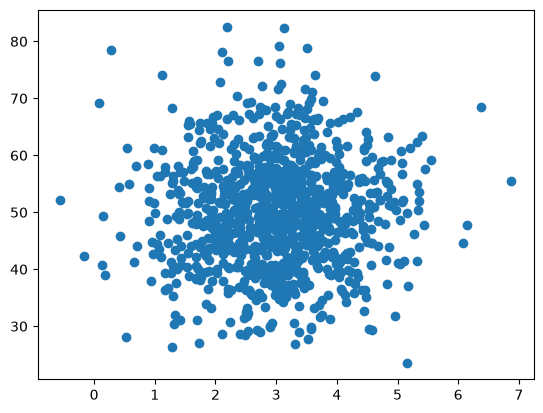

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def de_mean(x):
    xmean = np.mean(x)
    return [xi - xmean for xi in x] # Cálcula a diferença entre a média e o valor de x (`xi`) para termos a distância em relação a média.
                                    # no fim esses são os desvios em relação a média.
                                    # List comprehension em python.

def covariance(x, y):
    n = len(x)
    return np.dot(de_mean(x), de_mean(y)) / (n-1) # n é o tamanho da amostra 
                                                # calculamos o produto escalar e em seguida dividimos pelo tamanho da amostra.
                                                # `dot` (produto escalar) é a medida do ângulo entre dois vetores.
                                                # n - 1 pois estamos lidadndo com uma amostra (semelhante ao cálculo da variância
                                                # das aulas anteriores).

pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = np.random.normal(50.0, 10.0, 1000)

plt.scatter(pageSpeeds, purchaseAmount) # Como temos um scatter plot centralizado podemos observar a densidade toda espalhada
                                        # indicando que não a correlação nenhuma 

covariance(pageSpeeds, purchaseAmount) # Covariânacia próxima a zero, ou seja nenhuma relação.

Agora vamos fazer que a quantidade da compra (`amountPurchase`) seja uma função da velocidade da página (`pageSpeeds`), criando uma correlação bem real. O valor negativo indica uma relação inversa; Páginas que renderizam em menos tempo resultam em mais dinheiro gasto.

np.float64(-10.925537377849933)

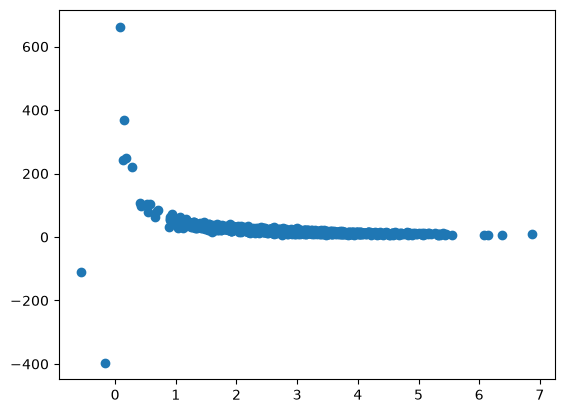

In [15]:
purchaseAmount = np.random.normal(50.0, 10.0, 1000) / pageSpeeds # Essa é a função da velocidade da página descrita
                                                                    # A relação é dada pela divisão `/`.

plt.scatter(pageSpeeds, purchaseAmount)

covariance(pageSpeeds, purchaseAmount) # Um valor distante de 0 e negativo, indicado uma relação inversa como descrito. 
                                        # Há uma curva feita pelo gráfico de densidade, indicando visualmente uma relação entre
                                        # os atributos.

Mas o que o valor da covariância sgnifica? Covariância é sensível as unidades usadas nas váriaveis, o que a torna difícil de interpretá-la. A correalação normaliza tudo através do desvio padrão, dando um entendimento mais fácil de entender pois o valor varia de -1 (correlação perfeita inversa) até 1 (correlação perfeita):

In [17]:
def correlation(x, y):
    stddevx = x.std()
    stddevy = y.std()
    return covariance(x,y) / stddevx / stddevy # Deveria conferir se não está dividindo por zero em cenários reais. 
                                                # Aqui é feita o normalização através do desvio padrão para cada elemento no vetor. 

correlation(pageSpeeds, purchaseAmount) # Uma correlação inversa próxima de -0.34 (Há alguma correlação mas não muita)

np.float64(-0.34244066797534267)

numpy pode calcular a correalação. Retorna a matriz de correlação de coeficientes entre cada combinação de arranjos informada:

In [20]:
np.corrcoef(pageSpeeds, purchaseAmount) # Temos um valor muito próximo ao que foi calculado anteriormente, 
                                        # entendendo como funciona por baixo dos panos através do fundamento 
                                        # apresentado.

array([[ 1.        , -0.34209823],
       [-0.34209823,  1.        ]])

(Não bate exatamente devido a precisão matemática disponível no computador.)

Podemos forçar uma correlação perfeita criando uma relação totalmente linear (novamente, não é exatamente -1 devido a erro de precisão, mas é próximo o suficiente para nos dizer que há uma ótima correlação ali): 

np.float64(-1.0010010010010009)

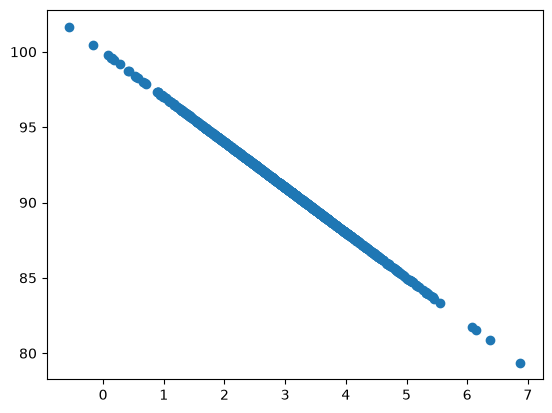

In [24]:
purchaseAmount = 100 - pageSpeeds * 3

plt.scatter(pageSpeeds, purchaseAmount)

correlation(pageSpeeds, purchaseAmount)

Lembre-se, correlação não indica causalidade! #

In [26]:
# A velocidade da página pode estar relacionada ao usuário ter uma internet melhor e não ao quanto gasta, por exemplo. Mas diz que a uma 
# correlação que vale a pena investigar.

## Atividade
numpy também tem a função `numpy.cov` que cálcula a variância. Tente usar para os dados de `pageSpeeds` e `purchaseAmounts` acima. Interprete os resultados, e compare os resultados da própria função de covâriancia feita. 

In [42]:
def cov_diff(x, y):
    '''Mostra os resutltados para comparar a função do NumPy e a função feita'''
    print(f'covariance: {covariance(x, y)}')

    n = len(x)
    print(f'np.cov    : {np.cov(x, y)[0,1]}') # Acesso a linha 0 na coluna 1 pois ele retorna uma matriz calculando a covariância 
                                                # de cada possibilidade.

# Valores inicais com distribuição normal para primeira comparação.
pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = np.random.normal(50.0, 10.0, 1000)

cov_diff(pageSpeeds, purchaseAmount) # possível notar valores muito próximos das ambas as funções.

covariance: -0.05979694853494035
np.cov    : -0.0597969485349407


In [43]:
purchaseAmount = np.random.normal(50.0, 10.0, 1000) / pageSpeeds # Segundo exemplo da aula
cov_diff(pageSpeeds, purchaseAmount)

covariance: -4.64567077167337
np.cov    : -4.645670771673369


In [44]:
purchaseAmount = 100 - pageSpeeds * 3 # Último exemplo da aula
cov_diff(pageSpeeds, purchaseAmount)

covariance: -2.942665439184777
np.cov    : -2.9426654391847773
